<a href="https://colab.research.google.com/github/Kadergueli/conflict-risk-analysis-chad/blob/main/04_spatial_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/ACLED_CHAD_RESEARCH/data/cleaned_acled_chad.csv')
df.head()

,EVENT_DATE,YEAR,TIME_PRECISION,EVENT_TYPE,INTERACTION,COUNTRY,ADMIN1,ADMIN2,ADMIN3,LOCATION,LATITUDE,LONGITUDE,GEO_PRECIS,FATALITIES
0,1997-02-15,1997,3,Violence against civilians,17,Chad,Logone Oriental,Nya Pendé,Mbaikoro,Moundou,"8,56670","16,08330",1,0
1,1997-02-15,1997,3,Violence against civilians,27,Chad,Logone Oriental,Nya Pendé,Kaba-Donia,Donia,"8,40509","16,42309",1,1
2,1997-02-15,1997,3,Violence against civilians,27,Chad,Logone Oriental,Lanya,Mbikou,Mbikou,"8,60141","16,39258",1,2
3,1997-07-15,1997,3,Battle-No change of territory,12,Chad,Guéra,Guéra,Mousmare,Bose,"11,07000","17,83000",2,40
4,1997-07-24,1997,2,Violence against civilians,37,Chad,Moyen-Chari,Lac Iro,Boum-Kebir,Boum-Kabir,"10,18000","19,39000",1,0


In [ ]:
# verification des coordonnées
df[['LATITUDE', 'LONGITUDE']].describe()

,LATITUDE,LONGITUDE
count,558,558
unique,154,149
top,"12,10850","15,04820"
freq,98,98


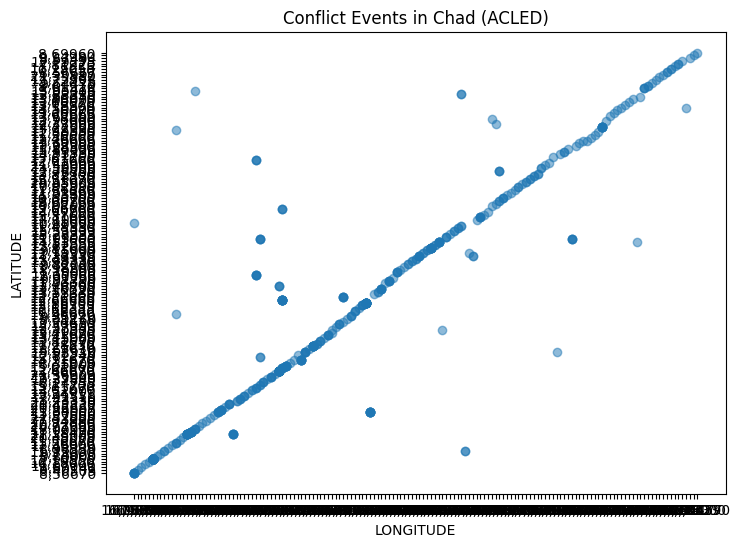

In [ ]:
# creation dd la carte
plt.figure(figsize=(8,6))

plt.scatter(df['LONGITUDE'], df['LATITUDE'], alpha=0.5)

plt.title("Conflict Events in Chad (ACLED)")
plt.xlabel("LONGITUDE")
plt.ylabel("LATITUDE")

plt.show()

## Observation
The scatter plot does not show a realistic geographic distribution. Most points form a near-perfect diagonal line, while a smaller number of points are scattered elsewhere.

## Interpretation
This pattern strongly suggests a data or plotting issue rather than true spatial conflict behavior. Latitude and longitude values may have been incorrectly matched, sorted independently, converted to strings, or plotted with formatting errors.

## Hypotheses
- Latitude and longitude columns may have been sorted separately.
- Coordinates may have been imported as text instead of numeric values.
- Index alignment may have been broken after cleaning or filtering.
- Duplicate or generated coordinates may be present.

## Limitations
- The current figure cannot be reliably used for spatial interpretation.
- Any hotspot conclusion from this chart would be misleading.
- Axis labels are overcrowded, reducing readability.

## Implications
- Recheck latitude and longitude data types and row alignment.
- Verify missing values, duplicates, and coordinate ranges.
- Replot using clean numeric coordinates before continuing spatial analysis.
- Spatial conclusions should be postponed until the issue is fixed.

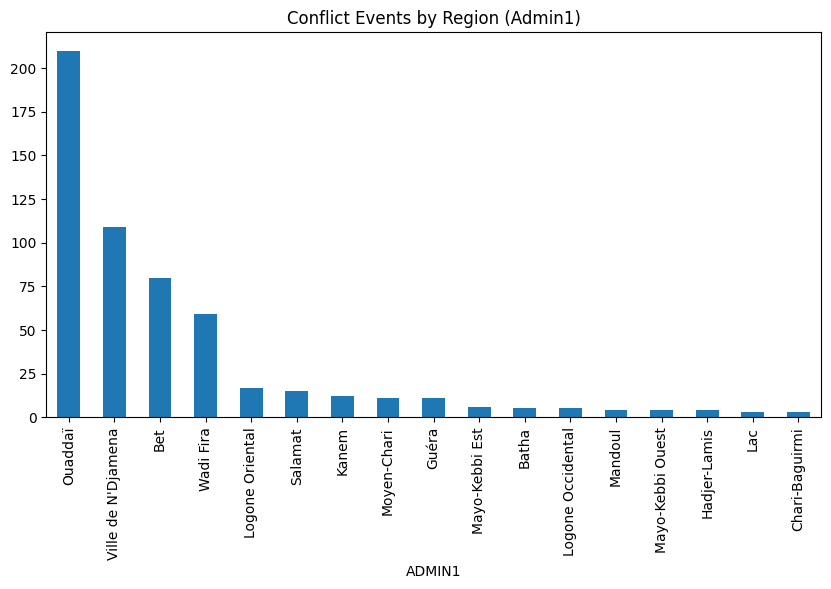

In [ ]:
#zones plus actives
df['ADMIN1'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Conflict Events by Region (Admin1)")
plt.show()

## Observation
The chart shows a strong geographic concentration of conflict events. Ouaddaï records by far the highest number of incidents, followed by N'Djamena, BET, and Wadi Fira. Most other regions report significantly lower levels.

## Interpretation
Conflict events are not evenly distributed across Chad. A limited number of regions appear as major hotspots, suggesting that insecurity is driven by localized regional dynamics rather than a uniform national pattern.

## Hypotheses
- Ouaddaï and Wadi Fira may be influenced by eastern border instability and cross-border movements.
- N'Djamena may reflect protests, political tensions, and stronger reporting coverage.
- BET may be linked to remote desert zones, mobility corridors, or weak territorial control.
- Lower counts in other regions may indicate relative stability or underreporting.

## Limitations
- Event counts depend on reporting access and media presence.
- More events do not always mean higher violence severity.
- Population size differences between regions are not considered.
- Administrative counts do not capture within-region variation.

## Implications
- Prioritize hotspot regions for deeper spatial investigation.
- Compare event frequency with fatalities to measure intensity.
- Use maps to identify border and corridor risk patterns.
- Develop region-specific prevention and security responses.

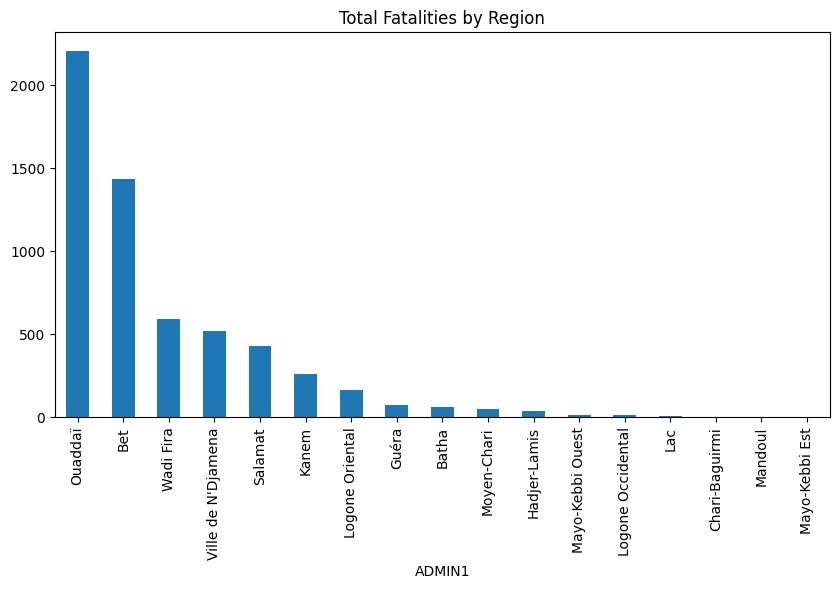

In [ ]:
#fatalitfatalité regions
risk = df.groupby('ADMIN1')['FATALITIES'].sum().sort_values(ascending=False)

risk.plot(kind='bar', figsize=(10,5))
plt.title("Total Fatalities by Region")
plt.show()

## Observation
Fatalities are heavily concentrated in a few regions. Ouaddaï records the highest death toll, followed by BET, Wadi Fira, and N'Djamena. Most remaining regions show much lower totals.

## Interpretation
Conflict severity is uneven across Chad. Some regions experience more lethal violence, showing that the deadliest areas are concentrated in specific zones rather than spread nationwide.

## Hypotheses
- Ouaddaï, BET, and Wadi Fira may face armed clashes, border insecurity, or weak state control.
- N'Djamena fatalities may reflect unrest or a small number of high-impact incidents.
- Lower totals elsewhere may indicate lower-intensity conflict or limited reporting.

## Limitations
- Fatality counts may be underestimated or delayed.
- High totals can result from a few major incidents.
- Death counts do not capture displacement or economic damage.
- Regional population differences are not considered.

## Implications
- Prioritize high-fatality regions for security and humanitarian response.
- Compare fatalities with event counts to assess lethality.
- Investigate major incidents driving death concentrations.
- Use fatality hotspots to improve regional risk mapping

In [ ]:
import folium

map_chad = folium.Map(location=[12.1, 15.0], zoom_start=6, tiles='OpenStreetMap')

In [ ]:
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        radius=3,
        fill=True
    ).add_to(map_chad)

map_chad